# U1 - Integrante 1 - Regresión de Monto (quote_qty)

Pipeline Bronze → Silver → Gold con PySpark, entrenamiento y comparación de modelos de regresión (Linear Regression vs Random Forest).

## 1. Configuración de Spark Session

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, BooleanType, TimestampType
from pyspark.sql.functions import col, when, date_format
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("U1-Integrante1-RegresionMonto")
    .master("local[*]")
    .config("spark.ui.port", "4040")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
        .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/11 19:23:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Carga Bronze con Esquema Explícito

In [2]:
schema = StructType([
    StructField("trade_id", LongType(), False),
    StructField("price", DoubleType(), True),
    StructField("qty", DoubleType(), True),
    StructField("quote_qty", DoubleType(), True),
    StructField("time_us", LongType(), False),
    StructField("is_buyer_maker", BooleanType(), True),
    StructField("is_best_match", BooleanType(), True)
])

df_bronze = spark.read.csv("/opt/data/BTCUSDT-trades-2026-01-05.csv", schema=schema, header=False)
df_bronze.printSchema()
df_bronze.show(5)

root
 |-- trade_id: long (nullable = true)
 |-- price: double (nullable = true)
 |-- qty: double (nullable = true)
 |-- quote_qty: double (nullable = true)
 |-- time_us: long (nullable = true)
 |-- is_buyer_maker: boolean (nullable = true)
 |-- is_best_match: boolean (nullable = true)

+----------+--------+-------+-----------+----------------+--------------+-------------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_buyer_maker|is_best_match|
+----------+--------+-------+-----------+----------------+--------------+-------------+
|5734054604|91529.74| 2.2E-4| 20.1365428|1767571200308618|         false|         true|
|5734054605|91529.74|   0.01|   915.2974|1767571200375801|         false|         true|
|5734054606|91529.74|0.00437|399.9849638|1767571200477157|         false|         true|
|5734054607|91529.74|0.00764|699.2872136|1767571200480543|         false|         true|
|5734054608|91529.74|0.00136|124.4804464|1767571200545508|         false|         true|
+--------

## 3. Capa Silver: Calidad, Transformaciones y Feature Engineering

In [3]:
df_silver = df_bronze.na.drop(subset=["trade_id", "price", "qty", "quote_qty"]) \
    .dropDuplicates(["trade_id"]) \
    .withColumn("time", (col("time_us") / 1000000).cast(TimestampType())) \
    .withColumn("is_buyer_maker_num", when(col("is_buyer_maker") == True, 1.0).otherwise(0.0))

df_silver.show(5)

[Stage 1:>                                                        (0 + 10) / 10]

+----------+--------+-------+-------------+----------------+--------------+-------------+--------------------+------------------+
|  trade_id|   price|    qty|    quote_qty|         time_us|is_buyer_maker|is_best_match|                time|is_buyer_maker_num|
+----------+--------+-------+-------------+----------------+--------------+-------------+--------------------+------------------+
|5734054604|91529.74| 2.2E-4|   20.1365428|1767571200308618|         false|         true|2026-01-05 00:00:...|               0.0|
|5734054610|91529.74| 5.4E-4|   49.4260596|1767571200665868|         false|         true|2026-01-05 00:00:...|               0.0|
|5734054624|91529.74|0.20378|18651.9304172|1767571202033686|         false|         true|2026-01-05 00:00:...|               0.0|
|5734054642|91529.73|0.00599|  548.2630827|1767571202551395|          true|         true|2026-01-05 00:00:...|               1.0|
|5734054646|91529.74| 9.0E-5|    8.2376766|1767571202941974|         false|         true|2

## 4. Capa Gold: Guardado y Lectura Parquet

In [4]:
df_silver.write.mode("overwrite").partitionBy("is_buyer_maker").parquet("/opt/artifacts/gold_integrante1")
df_gold = spark.read.parquet("/opt/artifacts/gold_integrante1")
df_gold.show(5)

+----------+--------+-------+-----------+----------------+-------------+--------------------+------------------+--------------+
|  trade_id|   price|    qty|  quote_qty|         time_us|is_best_match|                time|is_buyer_maker_num|is_buyer_maker|
+----------+--------+-------+-----------+----------------+-------------+--------------------+------------------+--------------+
|5734054607|91529.74|0.00764|699.2872136|1767571200480543|         true|2026-01-05 00:00:...|               0.0|         false|
|5734054608|91529.74|0.00136|124.4804464|1767571200545508|         true|2026-01-05 00:00:...|               0.0|         false|
|5734054614|91529.74|0.02555|2338.584857|1767571201085463|         true|2026-01-05 00:00:...|               0.0|         false|
|5734054628|91529.74|0.09835|9001.949929|1767571202033686|         true|2026-01-05 00:00:...|               0.0|         false|
|5734054663|91529.74| 9.0E-5|  8.2376766|1767571205115228|         true|2026-01-05 00:00:...|           

## 5. Ensamblado y Escalado de Vectores

In [5]:
assembler = VectorAssembler(inputCols=["price", "qty", "is_buyer_maker_num"], outputCol="features")
df_ml = assembler.transform(df_gold).select("features", col("quote_qty").alias("label"))

df_train, df_test = df_ml.randomSplit([0.8, 0.2], seed=42)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(df_train)
df_train_scaled = scaler_model.transform(df_train)
df_test_scaled = scaler_model.transform(df_test)

## 6. Modelo 1: Regresión Lineal Base

In [6]:
lr = LinearRegression(featuresCol="scaledFeatures", labelCol="label", regParam=0.1)
modelo_lr = lr.fit(df_train_scaled)
pred_lr = modelo_lr.transform(df_test_scaled)

netlib-blas: JNI_OnLoad: dlopen(libblas.so.3) failed: libblas.so.3: cannot open shared object file: No such file or directory
netlib-lapack: JNI_OnLoad: dlopen(liblapack.so.3) failed: liblapack.so.3: cannot open shared object file: No such file or directory
                                                                                

## 7. Modelo 2: Random Forest Regressor (Comparativo)

In [7]:
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20)
modelo_rf = rf.fit(df_train)
pred_rf = modelo_rf.transform(df_test)

## 8. Evaluación de Métricas (RMSE, MAE, R2)

In [8]:
eval_rmse = RegressionEvaluator(metricName="rmse")
eval_r2 = RegressionEvaluator(metricName="r2")

print(f"LinearRegression - RMSE: {eval_rmse.evaluate(pred_lr):.4f}, R2: {eval_r2.evaluate(pred_lr):.4f}")
print(f"RandomForest - RMSE: {eval_rmse.evaluate(pred_rf):.4f}, R2: {eval_r2.evaluate(pred_rf):.4f}")

LinearRegression - RMSE: 32.6655, R2: 0.9999


[Stage 41:==============================================>         (10 + 2) / 12]

RandomForest - RMSE: 3087.3443, R2: 0.3111


## 9. Guardar el Modelo Ganador

In [9]:
modelo_lr.write().overwrite().save("/opt/artifacts/modelo_ganador_integrante1")

# 10. VISUALIZACIÓN DE RESULTADOS Y MÉTRICAS

In [21]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
#!pip install matplotlib

/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/usr/local/lib/python3.10/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
                                                                                

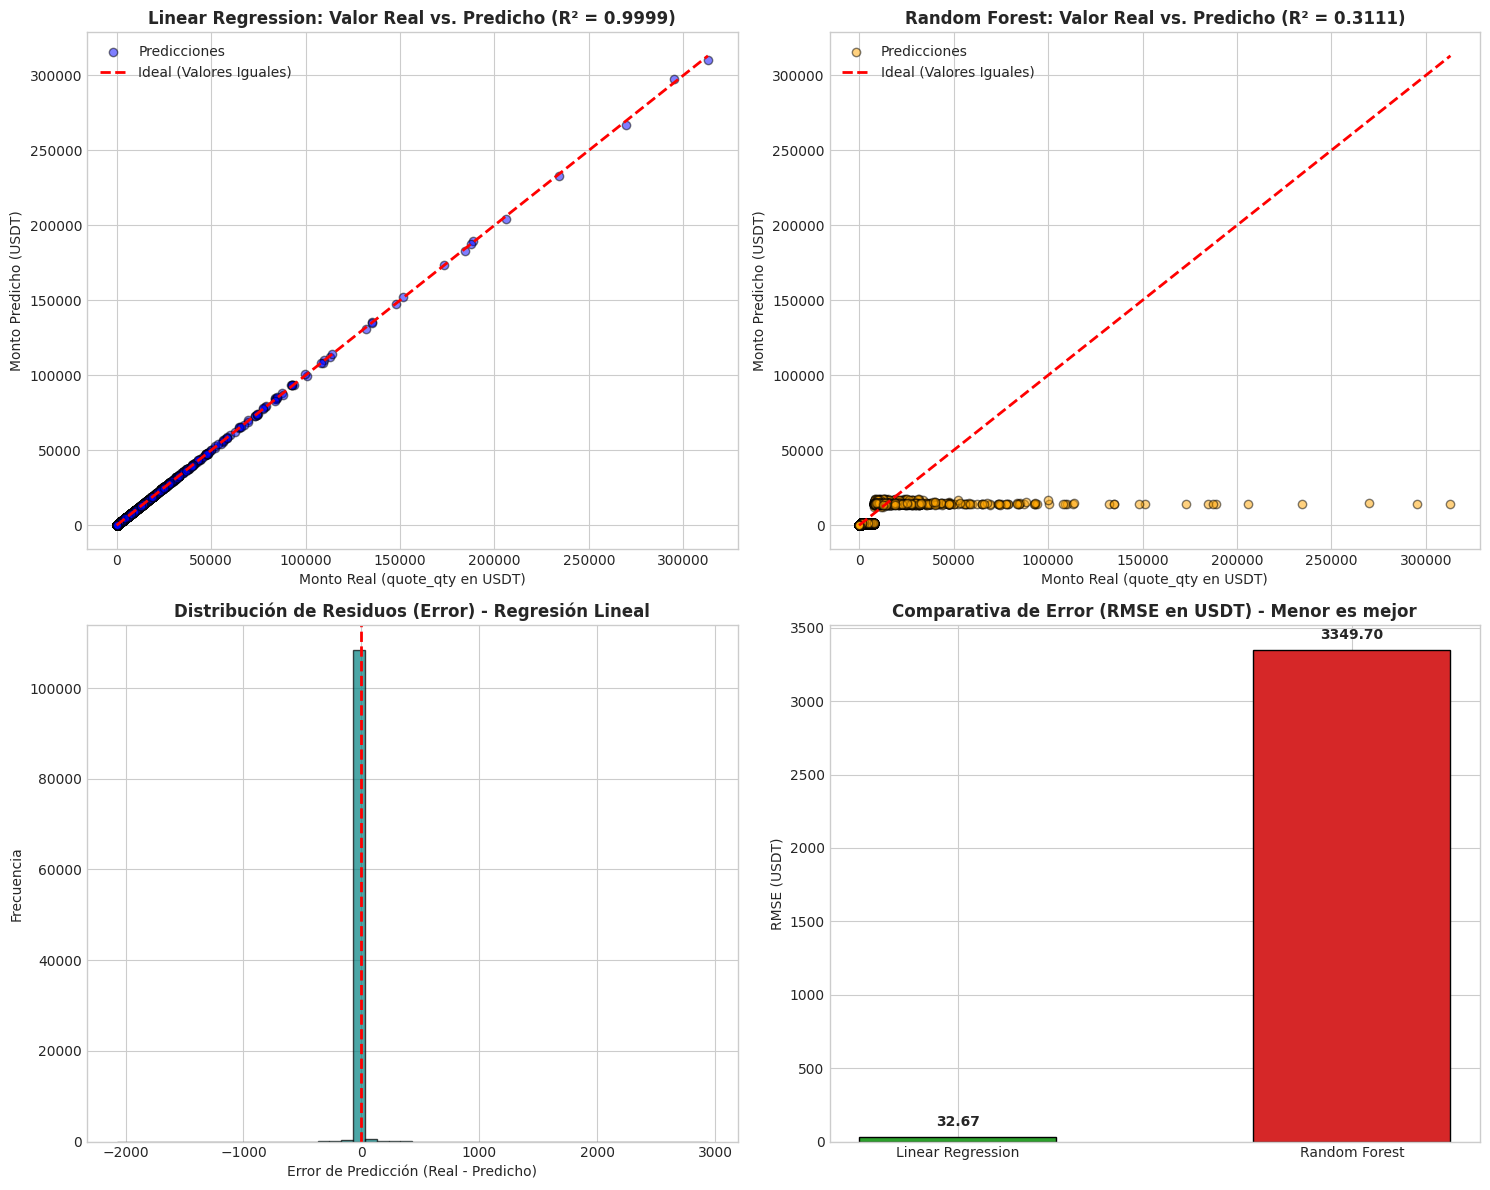

In [29]:
sample_lr = pred_lr.select("label", "prediction").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
sample_rf = pred_rf.select("label", "prediction").sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# -------------------------------------------------------------
# Gráfico 1: Real vs Predicho - Linear Regression
# -------------------------------------------------------------
axes[0, 0].scatter(sample_lr['label'], sample_lr['prediction'], alpha=0.5, color='blue', edgecolors='k', label='Predicciones')
# Línea ideal y=x
min_val = min(sample_lr['label'].min(), sample_lr['prediction'].min())
max_val = max(sample_lr['label'].max(), sample_lr['prediction'].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (Valores Iguales)')

axes[0, 0].set_title('Linear Regression: Valor Real vs. Predicho (R² = 0.9999)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Monto Real (quote_qty en USDT)')
axes[0, 0].set_ylabel('Monto Predicho (USDT)')
axes[0, 0].legend()

# -------------------------------------------------------------
# Gráfico 2: Real vs Predicho - Random Forest
# -------------------------------------------------------------
axes[0, 1].scatter(sample_rf['label'], sample_rf['prediction'], alpha=0.5, color='orange', edgecolors='k', label='Predicciones')
# Línea ideal y=x
min_val_rf = min(sample_rf['label'].min(), sample_rf['prediction'].min())
max_val_rf = max(sample_rf['label'].max(), sample_rf['prediction'].max())
axes[0, 1].plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], 'r--', lw=2, label='Ideal (Valores Iguales)')

axes[0, 1].set_title('Random Forest: Valor Real vs. Predicho (R² = 0.3111)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Monto Real (quote_qty en USDT)')
axes[0, 1].set_ylabel('Monto Predicho (USDT)')
axes[0, 1].legend()

# -------------------------------------------------------------
# Gráfico 3: Distribución de Errores / Residuos (Linear Regression)
# -------------------------------------------------------------
residuos_lr = sample_lr['label'] - sample_lr['prediction']
axes[1, 0].hist(residuos_lr, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Distribución de Residuos (Error) - Regresión Lineal', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Error de Predicción (Real - Predicho)')
axes[1, 0].set_ylabel('Frecuencia')

# -------------------------------------------------------------
# Gráfico 4: Comparación Directa de Métricas (RMSE)
# -------------------------------------------------------------
modelos = ['Linear Regression', 'Random Forest']
rmse_valores = [32.6655, 3349.6988]
colores = ['#2ca02c', '#d62728']  # Verde para el ganador, rojo para el peor

bars = axes[1, 1].bar(modelos, rmse_valores, color=colores, width=0.5, edgecolor='black')
axes[1, 1].set_title('Comparativa de Error (RMSE en USDT) - Menor es mejor', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('RMSE (USDT)')

# Agregar las etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()